# Análisis do dataset "Spotify Tracks Dataset"

Para referencia o dataset foi extraido do link: https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset/data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use('default')
pd.set_option('display.max_columns', None)

### 1. Carregando o dataset original

In [4]:
df = pd.read_csv('../data/raw/spotify-tracks-dataset.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.shape

(114000, 22)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

#### 1.1 Número de generos únicos

In [ ]:
df["track_genre"].nunique()

114

#### 1.2 Número de valores que estão faltando.

In [9]:
df.isnull().sum().sort_values(ascending=False)

album_name          1
artists             1
track_name          1
Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

#### 1.3 Número de músicas repetidas

In [10]:
df.duplicated().sum()

np.int64(0)

#### 1.4 Resumo Estatístico

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965


#### 1.5 Distribuição de popularidade

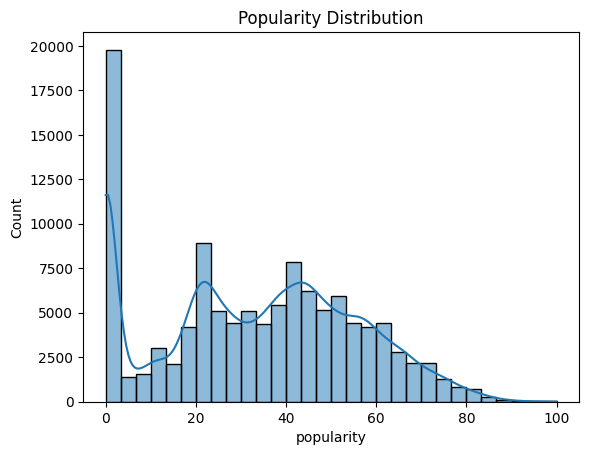

In [12]:
plt.figure()
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Popularity Distribution")
plt.show()

### 2. Análisis dos atributos músicas

In [13]:
audio_features = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

#### 2.1 Distribuição dos atributos musicais

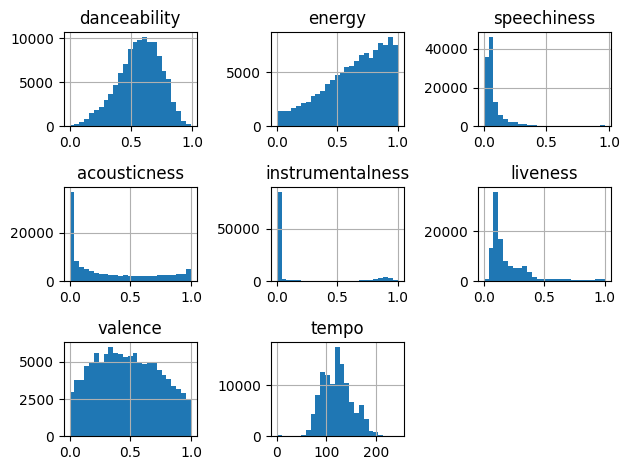

In [14]:
df[audio_features].hist(bins=25)
plt.tight_layout()
plt.show()

#### 2.2 Mapa de calor de correlação

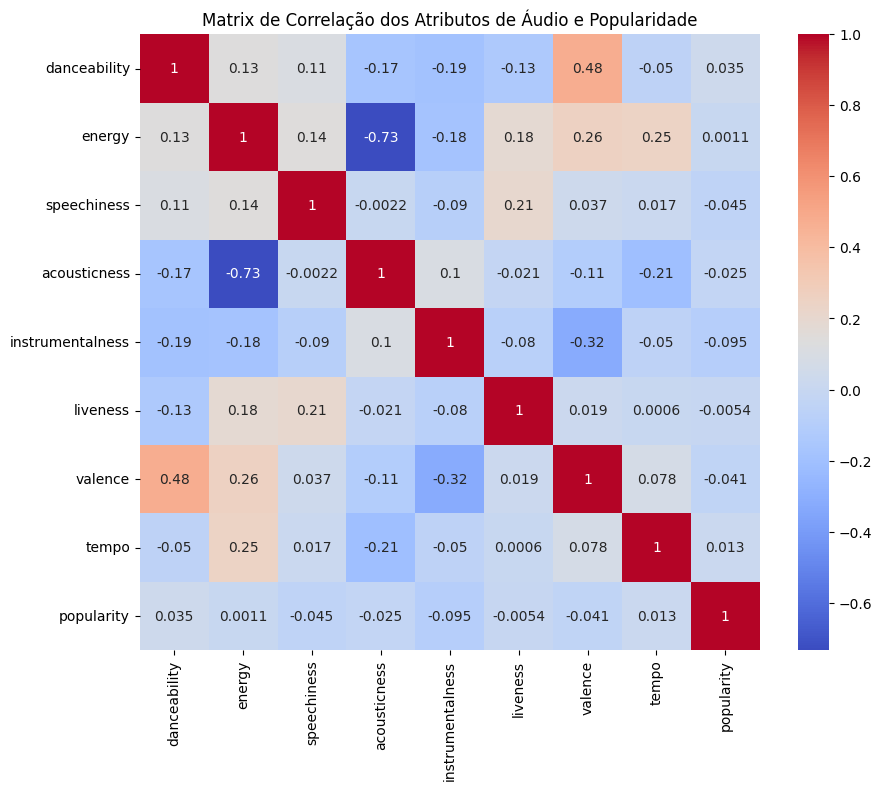

In [15]:
plt.figure(figsize=(10, 8))
corr = df[audio_features + ['popularity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrix de Correlação dos Atributos de Áudio e Popularidade")
plt.show()

In [16]:
df[audio_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)

popularity          1.000000
danceability        0.035448
tempo               0.013205
energy              0.001056
liveness           -0.005387
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64

### 3. Músicas mais populares (popularity >= 60)

In [31]:
df_most_populars = df[df['popularity'] > 60]
df_most_populars.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,13570.0,57421.512307,30810.197572,0.000000,31824.5000,57190.000000,81986.750000,113238.000
Unnamed: 0,13570.0,57421.512307,30810.197572,0.000000,31824.5000,57190.000000,81986.750000,113238.000
popularity,13570.0,69.151879,6.705737,61.000000,64.0000,68.000000,73.000000,100.000
duration_ms,13570.0,218812.499337,63482.841102,40000.000000,178933.0000,210840.000000,246770.500000,811077.000
danceability,13570.0,0.597207,0.158792,0.000000,0.4970,0.608000,0.715000,0.980
energy,13570.0,0.648720,0.220517,0.000020,0.5060,0.684000,0.823000,0.997
key,13570.0,5.348710,3.556602,0.000000,2.0000,5.000000,8.000000,11.000
loudness,13570.0,-7.384691,4.581708,-41.739000,-8.7015,-6.318000,-4.694500,1.023
mode,13570.0,0.609138,0.487962,0.000000,0.0000,1.000000,1.000000,1.000
speechiness,13570.0,0.076650,0.075854,0.000000,0.0349,0.047800,0.080800,0.828


In [32]:
df_most_populars.shape

(13570, 22)

#### 3.1 Distribuição dos gêneros músicais

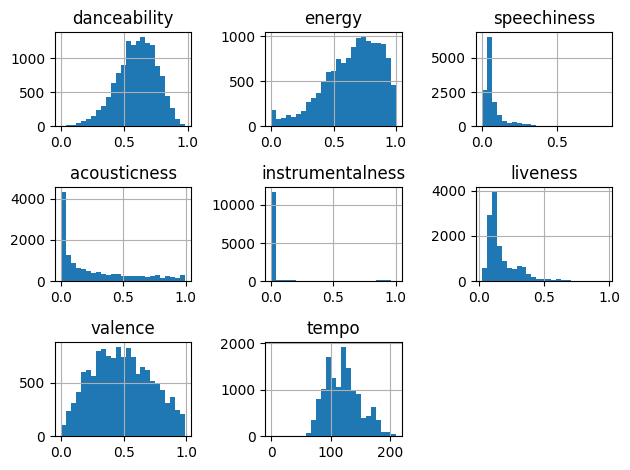

In [33]:
df_most_populars[audio_features].hist(bins=25)
plt.tight_layout()
plt.show()

### 4. Análisis dos generos

In [17]:
df['track_genre'].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

#### 4.1 Características médias de atributos de aúdio por gênero

In [18]:
with open('genres.txt', 'w') as f:
    for genre in sorted(df['track_genre'].unique()):
        f.write(f"{genre}\n")

In [20]:
selected_genres = [
    "pop",
    "rock",
    "hip hop",
    "r-n-b",
    "indie",
    "electronic",
    "jazz",
    "accoustic",
    "classical",
    "funk",
    "mbp",
    "samba",
    "sertanejo",
    'pagode',
    "forro",
    "latin",
    "reggaeton",
    "reggae",
    "soul",
    "alt-rock"
]

In [23]:
filtered_df = df[df['track_genre'].isin(selected_genres)]

genre_group = filtered_df.groupby('track_genre')[audio_features].mean()

genre_group


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,
alt-rock,0.534493,0.754173,0.055071,0.122162,0.054097,0.210249,0.518260,124.634404
classical,0.381923,0.189827,0.050831,0.920049,0.619208,0.166838,0.381050,107.949793
electronic,0.652945,0.694752,0.081768,0.177026,0.248697,0.190776,0.391839,122.947839
forro,0.649776,0.789526,0.057189,0.397576,0.001257,0.294971,0.760693,140.362197
funk,0.678184,0.632999,0.151649,0.299657,0.007798,0.180557,0.599653,117.755823
indie,0.587272,0.556192,0.062655,0.380386,0.052806,0.160361,0.467957,119.093452
jazz,0.509975,0.352954,0.055013,0.715816,0.079561,0.170025,0.490289,112.636469
latin,0.721902,0.727080,0.093123,0.183373,0.009177,0.174292,0.631149,119.812273
pagode,0.577723,0.712123,0.062787,0.538372,0.000566,0.519864,0.687978,126.859308


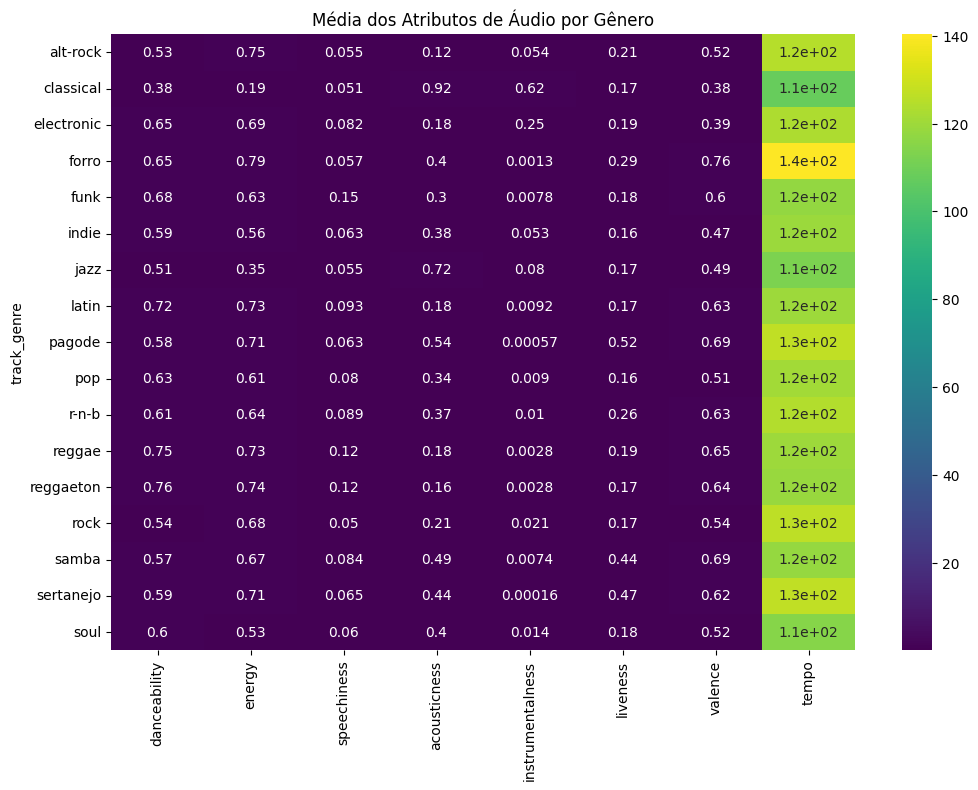

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(genre_group, annot=True, cmap='viridis')
plt.title("Média dos Atributos de Áudio por Gênero")
plt.show()

In [42]:
filtered_df.shape

(17000, 22)

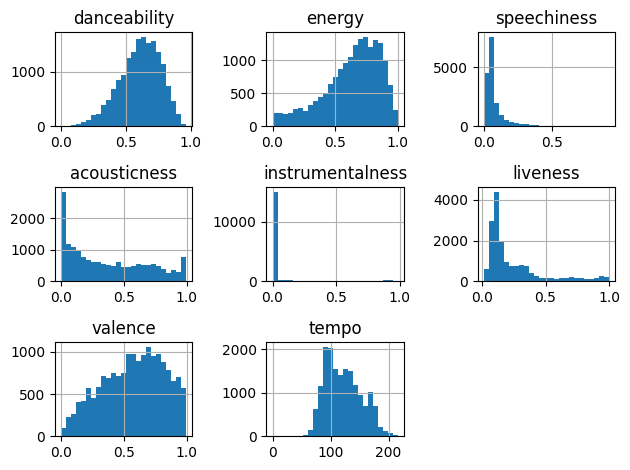

In [41]:
filtered_df[audio_features].hist(bins=25)
plt.tight_layout()
plt.show()

In [38]:
filtered_df_most_populars = filtered_df[filtered_df['popularity'] > 50]
filtered_df_most_populars.shape

(3722, 22)

In [39]:
filtered_df_most_populars["track_genre"].value_counts()

track_genre
pop           644
electronic    420
indie         414
alt-rock      347
soul          268
reggaeton     242
rock          232
sertanejo     209
funk          190
reggae        181
pagode        130
jazz          118
latin         107
r-n-b         106
classical      56
forro          39
samba          19
Name: count, dtype: int64

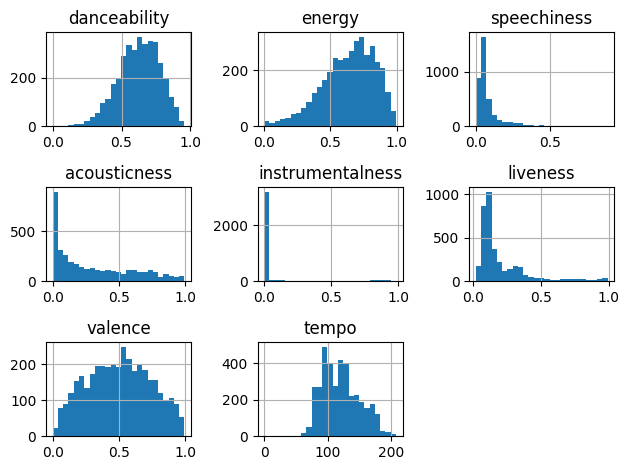

In [40]:
filtered_df_most_populars[audio_features].hist(bins=25)
plt.tight_layout()
plt.show()

### 5. Filtrando as músicas mais populares pelos gêneros

In [34]:
filtered_most_populars = df_most_populars[df_most_populars['track_genre'].isin(selected_genres)]

filtered_most_populars.shape

(2547, 22)

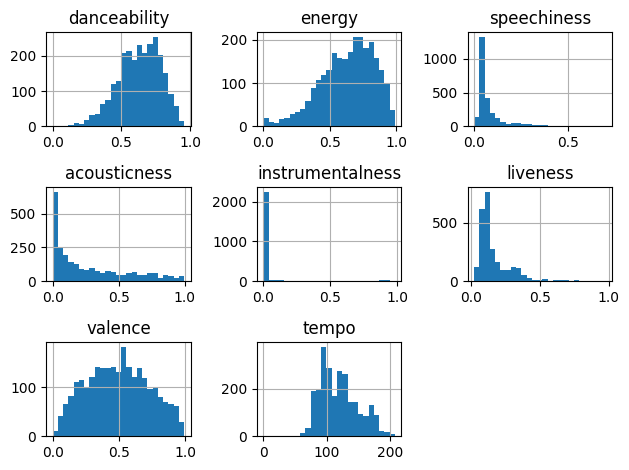

In [35]:
filtered_most_populars[audio_features].hist(bins=25)
plt.tight_layout()
plt.show()

In [36]:
# vendo o número de músicas por gênero entre as mais populares
filtered_most_populars['track_genre'].value_counts()

track_genre
pop           644
alt-rock      292
indie         284
rock          218
reggaeton     215
soul          210
reggae        152
electronic    134
funk          116
latin          82
r-n-b          75
jazz           68
classical      37
pagode         10
sertanejo       6
forro           2
samba           2
Name: count, dtype: int64

### 6. Salvando o dataset

In [43]:
# salvando o dataset filtrado para análise posterior
filtered_df.to_csv('../data/processed/spotify-tracks-filtered.csv', index=False)